# **Perturbation-based methods: RISE implementation**

Hello, friends! Welcome to a new tutorial :)  
This one is dedicated to a perturbation-based interpretation method — **RISE**.

#### **Mini-theory:**

Perturbation-based interpretation methods are built on the idea of answering the question:

> *"What will happen to the model's prediction if we change or remove a single feature?"*

The core idea of these methods is simple:  
we modify the input $x$ according to a predefined rule, pass the modified image $x'$ through the model, and record the change in prediction $\delta = f(x) - f(x')$.  
From this, the importance of a feature is defined through the sensitivity of the model to its perturbation.

These methods are particularly useful in situations where the structure and parameters of the model are unavailable (e.g., working only via an API).  
Unlike gradient-based approaches, they do **not** require access to internal weights or derivatives of the model.

Among the standard perturbation-based methods are **Occlusion**, **Ablation**, and **Permutation**.  
A less standard, but still frequently used approach is **RISE** (*Randomized Input Sampling for Explanation of Black-box Models*), which we will cover in detail in this tutorial.

**Its key steps are:**

1. Generate random binary masks over the input image.  
2. Apply these masks and pass the masked images through the model.  
3. Observe how the probability of the target class changes.  
4. Aggregate the results into a *feature importance map* as a weighted combination of masks.

The method addresses the problem of estimating over the enormous space of all possible binary masks  
(for a $32 \times 32$ image, there are already $2^{32 \times 32}$ such masks!).  
This is the crucial component of RISE and what makes it interesting to explore.

Let’s get started!



# **1. Importing libraries**

In [1]:
import torch
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights
import torchvision.transforms as T
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm


# **2. Data and model for demonstration**

For this demonstration, we will use a pretrained **ResNet50** and an image of a cat.  
However, you can upload and experiment with any image of your choice.


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/sabrinasadieh/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [02:55<00:00, 584kB/s] 


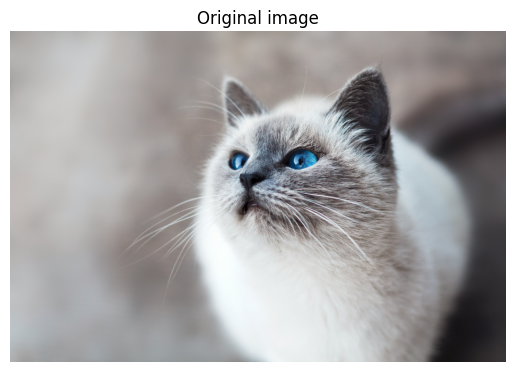

In [2]:
# Load the pretrained model
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
model.eval()

# Define preprocessing transforms
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225])
])

# Load the image
import requests, io
url = "https://github.com/SadSabrina/XAI-open_materials/blob/38216bfee2a38c96b4f1d16460040cb89527c3fe/yolo_nas_cam_tutorial/coco_test/cat.jpg?raw=True"
img = Image.open(requests.get(url, stream=True).raw).convert("RGB")

# Apply preprocessing
x = transform(img).unsqueeze(0)  # (1, 3, 224, 224)

# Show the image
plt.imshow(img)
plt.title("Original image")
plt.axis("off")
plt.show()


# **3. RISE: formulation and implementation**

## **3.1. Formulation**

Let:

- $f: I \to \mathbb{R}$ — a black-box model that, given an image $I$, outputs the confidence score for a target class.  
- $\Lambda = \{1,\dots,H\} \times \{1,\dots,W\}$ — the set of pixel coordinates $\lambda$.  
- $M: \Lambda \to \{0,1\}$ — a random binary mask sampled from distribution $D$.  

Then, the importance of pixel $\lambda$ is defined as the conditional expectation:

$$
Imp_{I,f}(\lambda) = \mathbb{E}_M \big[ f(I \odot M) \mid M(\lambda)=1 \big],
$$

where the operator $⊙$ denotes element-wise multiplication (masking the image).

**Intuition:** if keeping pixel $\lambda$ after masking significantly increases the probability of the target class, then this pixel is important for the prediction.

---

However, even for an image of size $32 \times 32$, the number of all possible masks equals $2^{32 \cdot 32}$, which is computationally intractable.  
Therefore, RISE applies two tricks:

1. **Rewriting the conditional expectation as an unconditional expectation.**  
   This is done using Bayes’ rule.

2. **Special mask generation with bilinear interpolation.**  
   Masks are first generated at low resolution with a given probability of keeping a pixel,  
   and then upsampled to the image resolution using bilinear interpolation.  
   This smooths the boundaries and makes the explanations more stable.

---

### **Hint 1. Rewriting with Bayes’ rule**

The original definition:

$$
Imp_{I,f}(\lambda) = \mathbb{E}_M \big[ f(I \odot M) \mid M(\lambda)=1 \big]
= \sum_{m} f(I \odot m)\, P\!\big(M=m \mid M(\lambda)=1\big).
$$

Working directly with the conditional probability is inconvenient, because it requires explicitly describing  
the distribution $P[M=m \mid M(\lambda)=1]$.  
Instead, the authors rewrite it as an unconditional expectation using Bayes’ rule:

$$
P(M=m \mid M(\lambda)=1) = \frac{P(M=m, M(\lambda)=1)}{P(M(\lambda)=1)}.
$$

Since:

$$
P(M=m,\, M(\lambda)=1) =
\begin{cases}
0, & m(\lambda)=0, \\[6pt]
P(M=m), & m(\lambda)=1,
\end{cases}
$$

all terms where $m(\lambda)=0$ vanish, and we obtain:

$$
Imp_{I,f}(\lambda) = \frac{1}{P[M(\lambda)=1]} \sum_{m} f(I \odot m)\, m(\lambda)\, P[M=m].
$$

The denominator $P[M(\lambda)=1]$ equals $\mathbb{E}[M]$,  
because the expectation of a binary (indicator) random variable is equal to the probability of the event it represents:

$$
\mathbb{E}[M(\lambda)] = 1 \cdot P(M(\lambda)=1) + 0 \cdot P(M(\lambda)=0) = P(M(\lambda)=1).
$$

---

### **Monte Carlo approximation**

To approximate the sum
$$\sum_{m} f(I \odot m)\, m(\lambda)\, P[M=m],$$
RISE applies the Monte Carlo method.  

Monte Carlo allows us to approximate expectations by random sampling.  
Formally, if $X$ is a random variable, then

$$
\mathbb{E}[X] \approx \frac{1}{N}\sum_{i=1}^N X_i,
$$

where $X_1, \dots, X_N$ are independent realizations of $X$.

---

In our case:  
- the random variable is $f(I \odot M)\, M(\lambda)$,  
- we sample $N$ random masks $M_1, \dots, M_N$ from distribution $D$,  
- for each mask we compute the model prediction $f(I \odot M_i)$,  
- multiply it by $M_i(\lambda)$ to only include masks where pixel $\lambda$ is preserved,  
- and average the results.

---

Thus, the Monte Carlo estimate of pixel importance is:

$$
S_{I,f}^{MC}(\lambda) \approx \frac{1}{N \cdot \mathbb{E}[M]}
\sum_{i=1}^N f(I \odot M_i)\, M_i(\lambda).
$$

Here:  
- the normalization $\tfrac{1}{N \cdot \mathbb{E}[M]}$ accounts for two factors:  
  1. division by $N$ corresponds to averaging over samples,  
  2. division by $\mathbb{E}[M] = P(M(\lambda)=1)$ corrects for the probability that a pixel is preserved;  
- $M_i(\lambda)$ is the value of the $i$-th mask at position $\lambda$:  
  - $M_i(\lambda)=1$ if pixel $\lambda$ is preserved in mask $M_i$,  
  - $M_i(\lambda)=0$ if it is masked out.  

Thus, $M_i(\lambda)$ serves as an **indicator** that “turns on” the contribution of $f(I \odot M_i)$ only when pixel $\lambda$ is actually present in the masked image.




### **Hint 2. Mask sampling with interpolation**

Switching to the unconditional probability solves the *mathematical* formulation issue,  
but it does **not** solve the *practical* problem of applying the Monte Carlo method in the full mask space $2^{H \times W}$.  

For the standard input size $224 \times 224$, direct independent sampling of pixels produces highly variable masks,  
which in turn lead to noisy estimates. To stabilize the saliency map in that case, an extremely large number of masks would be required.  

To address this, RISE introduces **sampling through interpolation**. The idea is to generate masks in 4 steps:

1. **Generate small binary masks.**  
   Masks of size $h \times w$ are created.  
   Each element is sampled from a Bernoulli distribution:  
   - value $1$ with probability $p$ (pixel preserved),  
   - value $0$ with probability $1-p$ (pixel masked).

2. **Upsample using bilinear interpolation.**  
   The small masks are enlarged to size  $$(h+1) \cdot C_H \times (w+1) \cdot C_W,$$  
   where $C_H \times C_W =  \frac{H}{h} \times \frac{W}{w}$ is the cell size after upsampling.  
   After bilinear interpolation, the mask is no longer strictly binary, but takes values in $[0,1]$.  
   This smooths the edges and makes the resulting importance map more continuous.

3. **Random shift.**  
   The upsampled mask is shifted by a random number of pixels along both axes.  
   This introduces extra variability and avoids artifacts from the regular grid.

4. **Cropping.**  
   After the shift, a window of size $H \times W$ is cropped to match the input image size.  
   This ensures that the final mask is ready for element-wise multiplication with $I$.

---

As a result, the masks are **smoothed and more stable**, but they still respect the probabilistic distribution with parameter $p$.


That's it — the theoretical part of RISE is complete. Now let's move on to implementing the method in code.

### **3.2 Implementation**

In essence, the implementation requires three steps:

1. Generate the masks;  
2. Apply the masks to the input image;  
3. Obtain the model predictions and average them.  


In [3]:
# Mask generation
# define sizes — original size, size of "mini-mask" space, interpolation size (the last one — according to the formula from the article)

# original
_, C, H, W = x.shape
print(f'H:{H}\nW:{W}')

# size of square mini masks s = h = w
s = 7
print(f'Masks size:{s}x{s}')

# cell size after upsampling - that is, how many pixels "after" one original pixel "before" encodes
(C_H, C_W) = (H//s, W//s)
print(f'C_H, C_W: {(C_H, C_W)}')

# size of enlarged mask - before cropping
up_h, up_w = (s+1)*C_H, (s+1)*C_W
print(f'Up size: {up_h}x{up_w}')

H:224
W:224
Masks size:7x7
C_H, C_W: (32, 32)
Up size: 256x256


In [4]:
# Generate N random masks with numbers from 0 to 1 and binarize them
N = 10
p = 0.5

grid = (torch.rand(N,1,s,s, device=x.device) < p).float()

# Expand masks based on bilinear interpolation
ups = F.interpolate(grid, size=(up_h, up_w), mode="bilinear", align_corners=False)

# Organize random shifts and crops
masks = torch.empty(N,1,H,W, device=x.device)
for i in range(N):
  dx = torch.randint(0, C_H, (1,), device=x.device).item() # shift x by random number from 0 to 32 (256-224)
  dy = torch.randint(0, C_W, (1,), device=x.device).item() # similar for y
  masks[i,0] = ups[i,0, dx:dx+H, dy:dy+W]

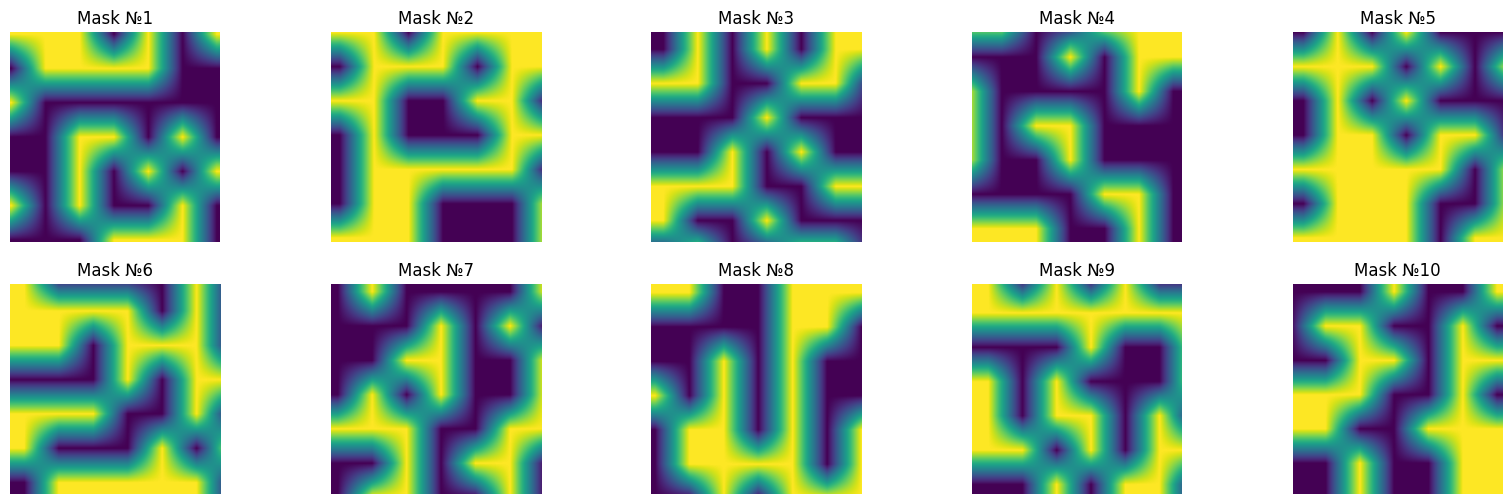

In [5]:
# Let's see results
masks_arr = masks.numpy().reshape((10, 224, 224))

fig, ax = plt.subplots(2, 5, figsize=(20, 6))
axes = ax.flatten()

for i in range(10):
  axes[i].imshow(masks_arr[i])
  axes[i].set_title(f'Mask №{i+1}')
  axes[i].axis('off');

Now we apply the mask to the image. We will apply it element-wise by multiplying.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6866082..2.4859147].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8416781..2.6174488].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7942142..2.4780636].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9160802..2.2616608].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7754089..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9800507..2.5602627].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9018748

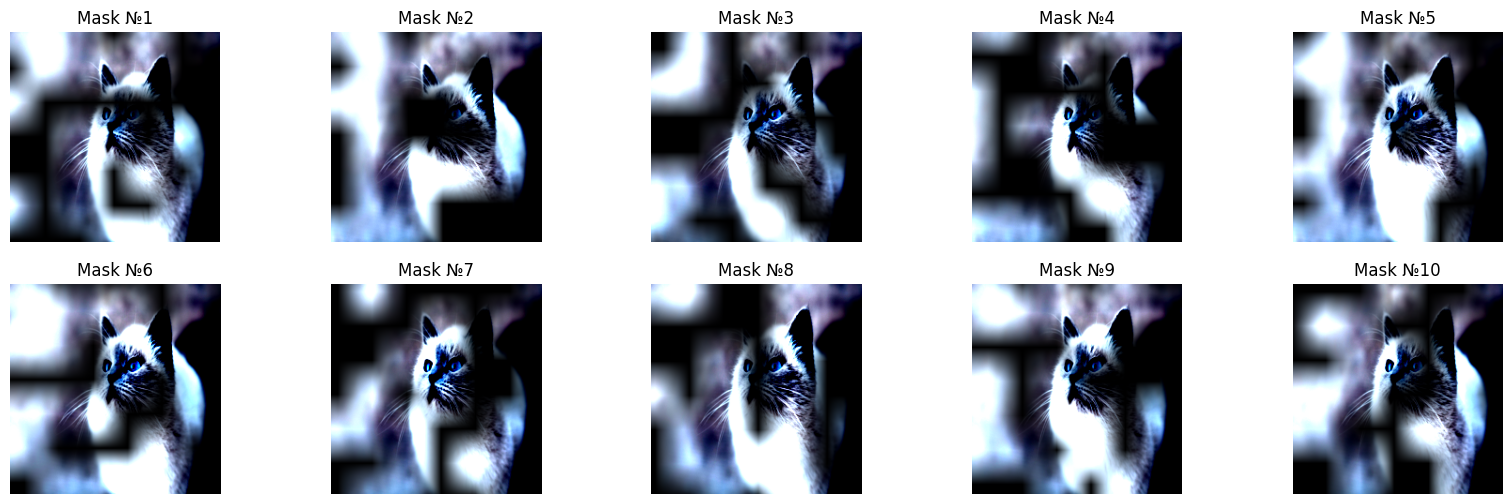

In [6]:
x_as_arr = x.permute(0, 2, 3, 1)[0].numpy()

fig, ax = plt.subplots(2, 5, figsize=(20, 6))
axes = ax.flatten()

for i in range(10):
  axes[i].imshow(masks_arr[i][..., None] * x_as_arr)
  axes[i].set_title(f'Mask №{i+1}')
  axes[i].axis('off');

All that remains is to get a forecast and average it.

In [7]:
model(x).softmax(dim=1).argmax().item()

284

100%|██████████| 10/10 [00:00<00:00, 32.38it/s]
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.622571].


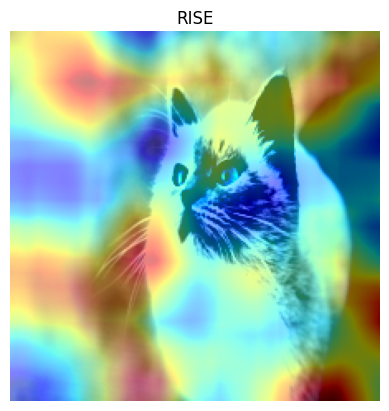

In [8]:
scores = []
class_id = model(x).softmax(dim=1).argmax().item()


with torch.no_grad():
  for i in tqdm(range(0, N)):

    stack = masks[i] * x        # (B,1,H,W)*(1,C,H,W) -> (B,C,H,W)
    out = model(stack).softmax(dim=1)        # probs
    scores.append(out)          # (B,)

  scores = torch.cat(scores, dim=0)                # (N,)
  # Take the column of the class of interest: (N,)
  scores = scores[:, class_id]

  # Let's get the MC estimate: (H*W,) = (1 x N) @ (N x H*W)
  sal = torch.matmul(scores.view(1, N), masks.view(N, H * W)).view(H, W)
  sal = sal / (N * p)


plt.imshow(x[0].permute(1, 2, 0).numpy())
plt.imshow(sal.cpu(), cmap="jet", alpha=0.5)
plt.axis("off")
plt.title("RISE")
plt.show()


Now let's wrap everything in a function and build a map with a larger number of masks.

In [9]:
def RISE(model, x, N, s, p, class_id):
  model.eval()

  if class_id is None:
    class_id = model(x).softmax(dim=1).argmax().item()
    print(f'Selected class: {class_id}')

  # sizes
  _, C, H, W = x.shape
  (C_H, C_W) = (H//s, W//s)
  up_h, up_w = (s+1)*C_H, (s+1)*C_W

  grid = (torch.rand(N,1,s,s, device=x.device) < p).float()
  ups = F.interpolate(grid, size=(up_h, up_w), mode="bilinear", align_corners=False)

  # shifts and crop
  masks = torch.empty(N,1,H,W, device=x.device)
  for i in range(N):
    dx = torch.randint(0, C_H, (1,), device=x.device).item() # сдвиг по x на случайное число от 0 до 32 (256-224)
    dy = torch.randint(0, C_W, (1,), device=x.device).item() # аналогично по y
    masks[i,0] = ups[i,0, dx:dx+H, dy:dy+W]

  # scores
  scores = []
  with torch.no_grad():
    for i in tqdm(range(0, N)):
      stack = masks[i] * x        # (B,1,H,W)*(1,C,H,W) -> (B,C,H,W)
      out = model(stack).softmax(dim=1)        # вероятности
      scores.append(out)          # (B,)

  scores = torch.cat(scores, dim=0)
  # class_id scores
  scores = scores[:, class_id]

  # Agg
  sal = torch.matmul(scores.view(1, N), masks.view(N, H * W)).view(H, W)
  sal = sal / (N * p)

  return sal


In [10]:
saliency_map_RISE1000 = RISE(model, x, 1000, 7, 0.5, None)

Selected class: 284


100%|██████████| 1000/1000 [00:22<00:00, 45.02it/s]


In [11]:
saliency_map_RISE100 = RISE(model, x, 100, 7, 0.5, None)
saliency_map_RISE10 = RISE(model, x, 10, 7, 0.5, None)

Selected class: 284


100%|██████████| 100/100 [00:02<00:00, 46.16it/s]


Selected class: 284


100%|██████████| 10/10 [00:00<00:00, 40.88it/s]


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.622571].


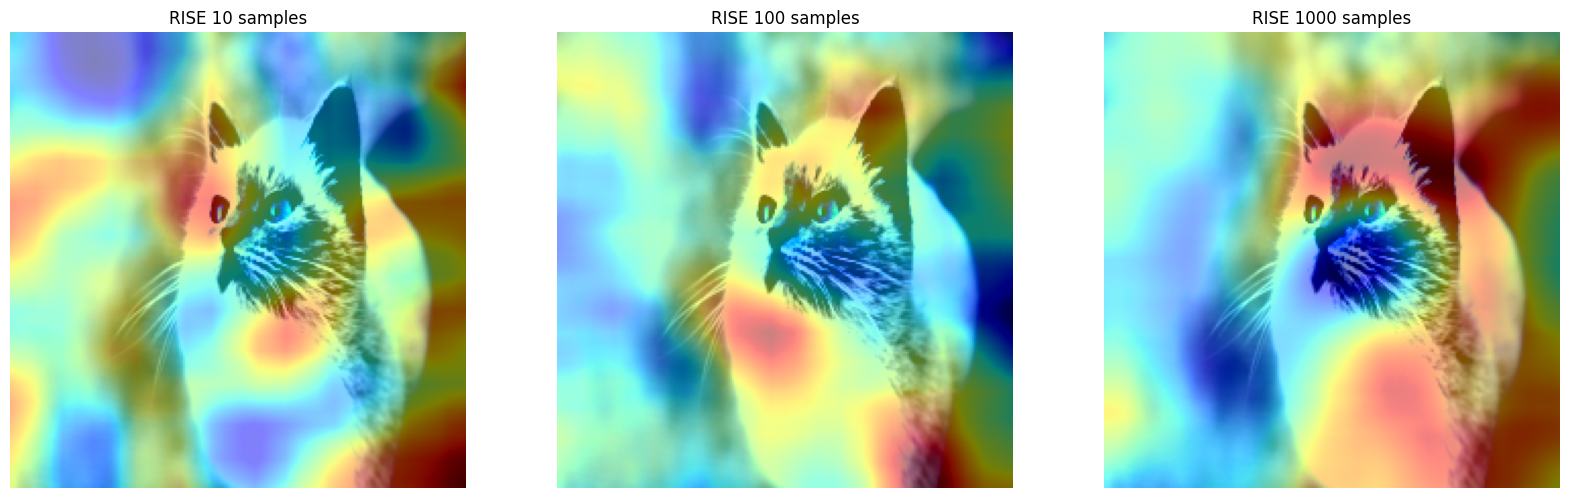

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

for i, map in enumerate([saliency_map_RISE10, saliency_map_RISE100, saliency_map_RISE1000]):
  ax[i].imshow(x[0].permute(1, 2, 0).numpy())
  ax[i].imshow(map.cpu(), cmap="jet", alpha=0.5)
  ax[i].axis("off")
  ax[i].set_title(f"RISE 10{'0'*i} samples")

plt.show()

As you can see, the manual implementation remains sensitive to the number of samples,  
and quite a large number of masks is still required for stable results.

With this, the tutorial comes to an end. Congratulations if you made it this far! 🎉  
In this tutorial, we explored the application of **RISE** for model interpretation. Specifically, we:

* introduced the idea of perturbation-based methods and formulated RISE using conditional expectation;  
* carefully derived the mathematical setup and showed the Bayes rule transformation;  
* implemented random mask generation and discussed the bilinear interpolation trick;  
* built the Monte Carlo approximation and computed importance maps for a given class;  
* visualized the results and confirmed that the method works even for complete black-box models.  

RISE enables interpretations without requiring access to model weights or gradients, which makes it a universal tool.  
However, keep in mind that the quality of the saliency maps depends on the number of generated masks and the sampling parameters (e.g., pixel retention probability).  
Try experimenting with different settings and compare the resulting maps with other methods (for example, [CAM](https://github.com/SadSabrina/XAI-open_materials/tree/main/CAM_yt), which also has a tutorial).

---

### **Main references:**
[1](https://arxiv.org/abs/1806.07421) — original RISE paper,  
[2](https://github.com/eclique/RISE) — official repository.

---

### **New materials:**
Stay tuned for updates in the [data blog](https://t.me/jdata_blog) and on [GitHub](https://github.com/SadSabrina/XAI-open_materials/tree/main)!

With best wishes,  
Your Data Author 💡

---

### **Code on GitHub and other resources:**
[github](https://github.com/SadSabrina/XAI-open_materials/blob/main/RISE/RISE_tutorial_eng.ipynb)

And of course, I’d be glad to connect on [LinkedIn](https://www.linkedin.com/in/sabrina-sadiekh-35181a286/).

